
📄 File: Subject00_2.edf
🔁 Reconstruction RMSE (25% samples): 6.2679
🧹 Denoising RMSE: 0.9260


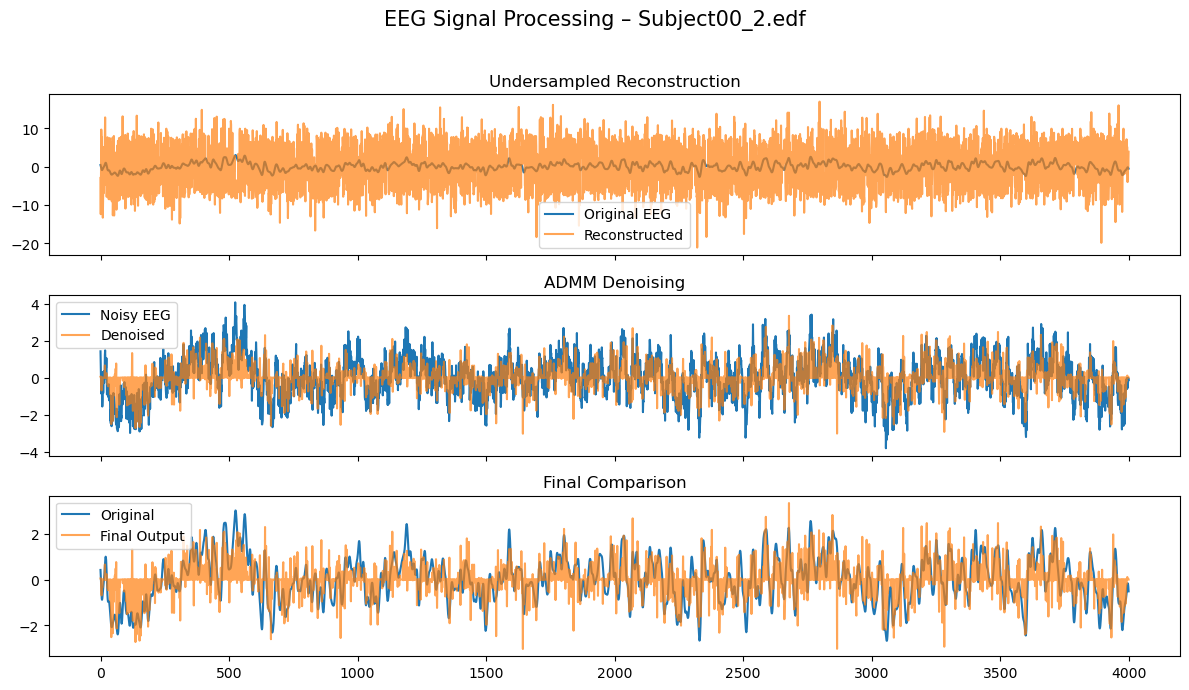

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pyedflib
import os

# ==== Constants ====
DATA_PATH = r'R:\AIE FILES\Semester-3\Projects\MFC3\Paper_1\eeg-during-mental-arithmetic-tasks-1.0.0'
SAMPLE_FRAC = 0.25
CHANNEL = 0            # EEG channel to read
LAMBDA = 0.1
RHO = 1.0
NOISE_STD = 0.5
ITER = 20              # Reduce for faster execution
MAX_LEN = 4000         # Truncate EEG length for speed and stability

# ==== Soft thresholding ====
def soft(x, thresh):
    return np.sign(x) * np.maximum(np.abs(x) - thresh, 0)

# ==== Load EDF files ====
edf_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('_2.edf')])
if not edf_files:
    raise FileNotFoundError("No '_2.edf' files found in the dataset path!")

# ==== Process each file ====
for file in edf_files[:1]:  # Limit to first file for now
    path = os.path.join(DATA_PATH, file)
    f = pyedflib.EdfReader(path)
    signal = f.readSignal(CHANNEL).astype(np.float64)
    f.close()
    
    signal = signal[:MAX_LEN]  # Truncate signal
    original = (signal - np.mean(signal)) / np.std(signal)  # Standardize
    N = len(original)
    M = int(SAMPLE_FRAC * N)

    # ==== Create random measurement matrix H ====
    H = np.random.randn(M, N) / np.sqrt(M)  # Scale to prevent overflow
    y = H @ original

    # ==== ISTA Reconstruction (Compressed Sensing) ====
    x_rec = np.zeros(N)
    for _ in range(ITER):
        grad = H.T @ (y - H @ x_rec)
        grad = np.clip(grad, -10, 10)  # Prevent exploding values
        x_rec = soft(x_rec + RHO * grad, LAMBDA)
        x_rec = np.nan_to_num(x_rec, nan=0.0, posinf=0.0, neginf=0.0)

    rmse_rec = np.sqrt(np.mean((original - x_rec) ** 2))

    # ==== Add Noise to Signal ====
    noisy = original + np.random.normal(0, NOISE_STD, N)

    # ==== ADMM Denoising ====
    x = np.zeros(N)
    z = np.zeros(N)
    u = np.zeros(N)
    p = 1.0
    A = H.T @ H + p * np.eye(N)  # Precompute for speed

    for _ in range(ITER):
        b = H.T @ y + p * (z - u)
        x = np.linalg.solve(A, b)
        z = soft(x + u, LAMBDA / p)
        u = u + x - z

    rmse_denoise = np.sqrt(np.mean((original - z) ** 2))

    # ==== Print Results ====
    print(f'\n📄 File: {file}')
    print(f'🔁 Reconstruction RMSE (25% samples): {rmse_rec:.4f}')
    print(f'🧹 Denoising RMSE: {rmse_denoise:.4f}')

    # ==== Plotting ====
    fig, axs = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    axs[0].plot(original, label='Original EEG')
    axs[0].plot(x_rec, label='Reconstructed', alpha=0.7)
    axs[0].legend(); axs[0].set_title('Undersampled Reconstruction')

    axs[1].plot(noisy, label='Noisy EEG')
    axs[1].plot(z, label='Denoised', alpha=0.7)
    axs[1].legend(); axs[1].set_title('ADMM Denoising')

    axs[2].plot(original, label='Original')
    axs[2].plot(z, label='Final Output', alpha=0.7)
    axs[2].legend(); axs[2].set_title('Final Comparison')

    plt.suptitle(f'EEG Signal Processing – {file}', fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



📄 File: Subject00_2.edf
✅ RMSE Reconstruction (25% samples): 0.9169
🧹 RMSE Denoising (Gaussian + Laplacian): 0.8004


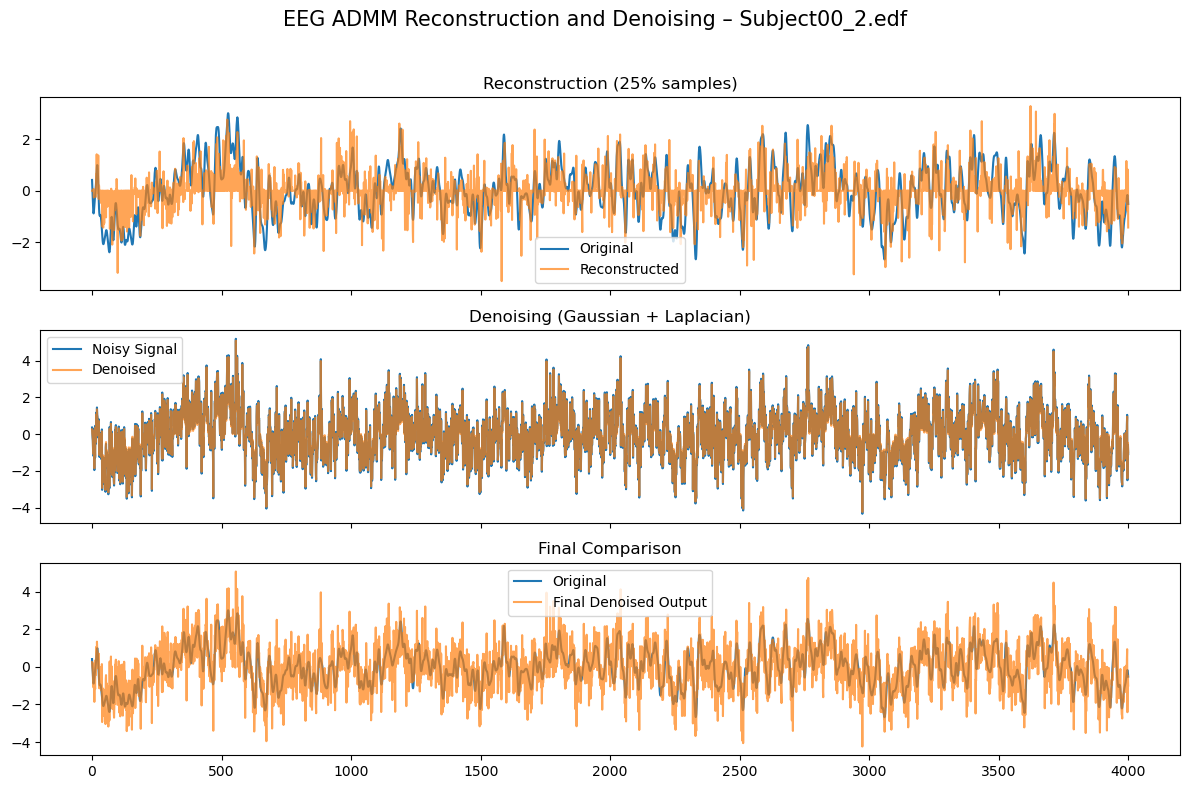

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pyedflib
import os

# Constants
DATA_PATH = r'R:\AIE FILES\Semester-3\Projects\MFC3\Paper_1\eeg-during-mental-arithmetic-tasks-1.0.0'
SAMPLE_FRAC = 0.25
CHANNEL = 0
LAMBDA = 0.1
RHO = 1.0
ITER = 20
MAX_LEN = 4000

def soft(x, thresh):
    return np.sign(x) * np.maximum(np.abs(x) - thresh, 0)

edf_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('_2.edf')])
for file in edf_files[:1]:  # Just first file
    path = os.path.join(DATA_PATH, file)
    f = pyedflib.EdfReader(path)
    signal = f.readSignal(CHANNEL).astype(np.float64)
    f.close()
    signal = signal[:MAX_LEN]
    
    original = (signal - np.mean(signal)) / np.std(signal)
    N = len(original)
    M = int(SAMPLE_FRAC * N)
    
    # Reconstruction Phase
    H = np.random.randn(M, N) / np.sqrt(M)
    y = H @ original

    x = np.zeros(N)
    z = np.zeros(N)
    u = np.zeros(N)
    A = H.T @ H + RHO * np.eye(N)

    for _ in range(ITER):
        b = H.T @ y + RHO * (z - u)
        x = np.linalg.solve(A, b)
        z = soft(x + u, LAMBDA / RHO)
        u = u + x - z

    x_rec = z
    rmse_rec = np.sqrt(np.mean((original - x_rec) ** 2))

    # Denoising Phase (Add Gaussian + Laplacian)
    gaussian_noise = np.random.normal(0, 0.5, N)
    laplacian_noise = np.random.laplace(0, 0.5, N)
    noisy_signal = original + gaussian_noise + laplacian_noise

    y_denoise = noisy_signal
    x = np.zeros(N)
    z = np.zeros(N)
    u = np.zeros(N)
    for _ in range(ITER):
        x = (y_denoise + RHO * (z - u)) / (1 + RHO)
        z = soft(x + u, LAMBDA / RHO)
        u = u + x - z

    x_denoised = z
    rmse_denoise = np.sqrt(np.mean((original - x_denoised) ** 2))

    print(f'\n📄 File: {file}')
    print(f'✅ RMSE Reconstruction (25% samples): {rmse_rec:.4f}')
    print(f'🧹 RMSE Denoising (Gaussian + Laplacian): {rmse_denoise:.4f}')

    # Plotting
    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axs[0].plot(original, label='Original')
    axs[0].plot(x_rec, label='Reconstructed', alpha=0.7)
    axs[0].set_title("Reconstruction (25% samples)")
    axs[0].legend()

    axs[1].plot(noisy_signal, label='Noisy Signal')
    axs[1].plot(x_denoised, label='Denoised', alpha=0.7)
    axs[1].set_title("Denoising (Gaussian + Laplacian)")
    axs[1].legend()

    axs[2].plot(original, label='Original')
    axs[2].plot(x_denoised, label='Final Denoised Output', alpha=0.7)
    axs[2].set_title("Final Comparison")
    axs[2].legend()

    plt.suptitle(f'EEG ADMM Reconstruction and Denoising – {file}', fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
